In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
import numpy as np
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [44]:
import pandas as pd

#Subimos la base de datos
df_final = pd.read_excel('/content/df_final.xlsx')
df_final

,precio_mxn,superficie_total,superficie_cubierta,pisos,cuartos,lat,lon
0,4018046.42,174,312,1,1,18.964255,-98.289796
1,3356848.90,135,245,1,1,19.044477,-98.328011
2,1322395.03,90,90,1,1,19.066868,-98.282498
3,1780147.09,170,170,1,1,19.083184,-98.319795
4,5391302.77,168,330,1,1,19.044477,-98.328011
...,...,...,...,...,...,...,...
790,610336.01,67,63,1,1,18.994194,-98.249329
791,2242985.31,163,163,1,1,19.067272,-98.312950
792,4831828.07,200,260,1,1,19.044477,-98.328011
793,1861525.23,92,185,1,1,18.989595,-98.203529


In [45]:
# MODELO BASE

# Definimos la variable dependiente (Y)
Y = df_final['precio_mxn']

# Definimos las variables independientes (X)
X = df_final[['superficie_total', 'pisos', 'lat', 'lon']]

# Agregar el intercepto al modelo
X = sm.add_constant(X)

modelo_base_1 = sm.OLS(Y, X).fit()

print(modelo_base_1.summary())

                            OLS Regression Results                            
Dep. Variable:             precio_mxn   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     262.5
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          2.00e-143
Time:                        04:57:01   Log-Likelihood:                -12489.
No. Observations:                 795   AIC:                         2.499e+04
Df Residuals:                     790   BIC:                         2.501e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -5.796e+08   5.51e+07  

In [46]:
#Diagnosticos

#Breusch-Pagan (Heteroscedasticidad)
# H0: No hay heteroscedasticidad
# H1: hay heteroscedasticidad
bp_test = sms.het_breuschpagan(modelo_base_1.resid, modelo_base_1.model.exog)
print("\n2. Prueba de Breusch-Pagan para Heteroscedasticidad:")
print(f"Estadístico LM: {bp_test[0]:.4f}")
print(f"Valor p (LM): {bp_test[1]:.4e}")
if bp_test[1] < 0.05:
    print("Conclusión: Se rechaza H0 (Hay evidencia de Heteroscedasticidad).")
else:
    print("Conclusión: No se rechaza H0 (Hay Homoscedasticidad).")
print("-" * 50)




2. Prueba de Breusch-Pagan para Heteroscedasticidad:
Estadístico LM: 143.4577
Valor p (LM): 5.1317e-30
Conclusión: Se rechaza H0 (Hay evidencia de Heteroscedasticidad).
--------------------------------------------------


#Haciendo cambios de varibales y nuevos ajustes con las distancias, y superficies

In [47]:
#Limpiamos la base de datos
df_final = df_final.dropna(subset=['precio_mxn', 'superficie_total', 'lat', 'lon'])

#Tomamos en cuenta Puebla Capital, para el calculo de la nueva variable de distancial al centro
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

zocalo_lat, zocalo_lon = 19.0436, -98.1981

df_final['distancia_centro_km'] = df_final.apply(
    lambda row: haversine(row['lat'], row['lon'], zocalo_lat, zocalo_lon),
    axis=1
)



#Mapa
lat_center = df_final['lat'].mean()
lon_center = df_final['lon'].mean()

fig = px.scatter_mapbox(
    df_final,
    lat="lat",
    lon="lon",
    color="precio_mxn",
    size="superficie_total",
    center={"lat": lat_center, "lon": lon_center},
    zoom=10,
    hover_data=["precio_mxn", "cuartos", "distancia_centro_km"],
    title="Geolocalización de Viviendas en Puebla"
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()


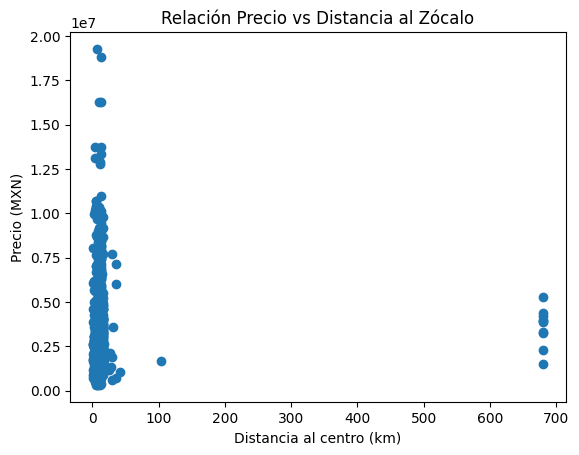

In [48]:
#Ajuste Precio-Distancia
plt.scatter(df_final['distancia_centro_km'], df_final['precio_mxn'])
plt.xlabel("Distancia al centro (km)")
plt.ylabel("Precio (MXN)")
plt.title("Relación Precio vs Distancia al Zócalo")
plt.show()

In [49]:

#Modelo
if 'cuartos' not in df_final.columns:
    df_final['cuartos'] = 1

y = df_final['precio_mxn']

X = df_final[['cuartos', 'superficie_total', 'lat', 'lon', 'distancia_centro_km']]

X = X.dropna()
y = y.loc[X.index]

X = sm.add_constant(X)

modelo_base_2 = sm.OLS(y, X).fit()

print(modelo_base_2.summary())

                            OLS Regression Results                            
Dep. Variable:             precio_mxn   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.559
Method:                 Least Squares   F-statistic:                     202.1
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.39e-138
Time:                        04:57:01   Log-Likelihood:                -12497.
No. Observations:                 795   AIC:                         2.501e+04
Df Residuals:                     789   BIC:                         2.503e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -5.382e+08   9

In [50]:
#Diagnosticos
#Breusch-Pagan (Heteroscedasticidad)
# H0: No hay heteroscedasticidad
# H1: hay heteroscedasticidad
bp_test = sms.het_breuschpagan(modelo_base_2.resid, modelo_base_2.model.exog)
print("\n2. Prueba de Breusch-Pagan para Heteroscedasticidad:")
print(f"Estadístico LM: {bp_test[0]:.4f}")
print(f"Valor p (LM): {bp_test[1]:.4e}")
if bp_test[1] < 0.05:
    print("Conclusión: Se rechaza H0 (Hay evidencia de Heteroscedasticidad).")
else:
    print("Conclusión: No se rechaza H0 (Hay Homoscedasticidad).")
print("-" * 50)


2. Prueba de Breusch-Pagan para Heteroscedasticidad:
Estadístico LM: 139.7089
Valor p (LM): 2.0632e-28
Conclusión: Se rechaza H0 (Hay evidencia de Heteroscedasticidad).
--------------------------------------------------


#Segunda opción con outliers

In [51]:
#Outliers
Q1 = df_final['precio_mxn'].quantile(0.25)
Q3 = df_final['precio_mxn'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_final = df_final[(df_final['precio_mxn'] >= lower_bound) & (df_final['precio_mxn'] <= upper_bound)]

#Correlaciones
corr_matrix = df_final[['precio_mxn', 'superficie_total', 'distancia_centro_km']].corr()
print(corr_matrix)
df_final


                     precio_mxn  superficie_total  distancia_centro_km
precio_mxn             1.000000          0.619200             0.053538
superficie_total       0.619200          1.000000             0.011004
distancia_centro_km    0.053538          0.011004             1.000000


,precio_mxn,superficie_total,superficie_cubierta,pisos,cuartos,lat,lon,distancia_centro_km
0,4018046.42,174,312,1,1,18.964255,-98.289796,13.068223
1,3356848.90,135,245,1,1,19.044477,-98.328011,13.655165
2,1322395.03,90,90,1,1,19.066868,-98.282498,9.240012
3,1780147.09,170,170,1,1,19.083184,-98.319795,13.525899
4,5391302.77,168,330,1,1,19.044477,-98.328011,13.655165
...,...,...,...,...,...,...,...,...
790,610336.01,67,63,1,1,18.994194,-98.249329,7.693095
791,2242985.31,163,163,1,1,19.067272,-98.312950,12.354599
792,4831828.07,200,260,1,1,19.044477,-98.328011,13.655165
793,1861525.23,92,185,1,1,18.989595,-98.203529,6.032143


In [52]:
#Modelo 3
if 'cuartos' not in df_final.columns:
    df_final['cuartos'] = 0

y = df_final['precio_mxn']

X = df_final[['cuartos', 'superficie_total', 'lat', 'lon', 'distancia_centro_km']]

X = X.dropna()
y = y.loc[X.index]

X = sm.add_constant(X)

modelo_base_3 = sm.OLS(y, X).fit()

print(modelo_base_3.summary())


                            OLS Regression Results                            
Dep. Variable:             precio_mxn   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     140.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          3.42e-104
Time:                        04:57:01   Log-Likelihood:                -11262.
No. Observations:                 735   AIC:                         2.254e+04
Df Residuals:                     729   BIC:                         2.256e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -4.575e+08   6

In [53]:
#Diagnosticos
#Breusch-Pagan (Heteroscedasticidad)
# H0: No hay heteroscedasticidad
# H1: hay heteroscedasticidad
bp_test = sms.het_breuschpagan(modelo_base_3.resid, modelo_base_3.model.exog)
print("\n2. Prueba de Breusch-Pagan para Heteroscedasticidad:")
print(f"Estadístico LM: {bp_test[0]:.4f}")
print(f"Valor p (LM): {bp_test[1]:.4e}")
if bp_test[1] < 0.05:
    print("Conclusión: Se rechaza H0 (Hay evidencia de Heteroscedasticidad).")
else:
    print("Conclusión: No se rechaza H0 (Hay Homoscedasticidad).")
print("-" * 50)


2. Prueba de Breusch-Pagan para Heteroscedasticidad:
Estadístico LM: 111.3422
Valor p (LM): 2.1321e-22
Conclusión: Se rechaza H0 (Hay evidencia de Heteroscedasticidad).
--------------------------------------------------


In [54]:
#Modelo sin lat y lon

if 'cuartos' not in df_final.columns:
    df_final['cuartos'] = 0

y = df_final['precio_mxn']

X = df_final[['cuartos', 'superficie_total', 'distancia_centro_km']]

X = X.dropna()
y = y.loc[X.index]

X = sm.add_constant(X)

modelo_base_4 = sm.OLS(y, X).fit()

print(modelo_base_4.summary())

                            OLS Regression Results                            
Dep. Variable:             precio_mxn   R-squared:                       0.389
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     155.0
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           9.27e-78
Time:                        04:57:02   Log-Likelihood:                -11329.
No. Observations:                 735   AIC:                         2.267e+04
Df Residuals:                     731   BIC:                         2.268e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1.716e+06   1

In [55]:
#Diagnosticos
#Breusch-Pagan (Heteroscedasticidad)
# H0: No hay heteroscedasticidad
# H1: hay heteroscedasticidad
bp_test = sms.het_breuschpagan(modelo_base_4.resid, modelo_base_4.model.exog)
print("\n2. Prueba de Breusch-Pagan para Heteroscedasticidad:")
print(f"Estadístico LM: {bp_test[0]:.4f}")
print(f"Valor p (LM): {bp_test[1]:.4e}")
if bp_test[1] < 0.05:
    print("Conclusión: Se rechaza H0 (Hay evidencia de Heteroscedasticidad).")
else:
    print("Conclusión: No se rechaza H0 (Hay Homoscedasticidad).")
print("-" * 50)


2. Prueba de Breusch-Pagan para Heteroscedasticidad:
Estadístico LM: 105.0290
Valor p (LM): 1.2880e-22
Conclusión: Se rechaza H0 (Hay evidencia de Heteroscedasticidad).
--------------------------------------------------


In [56]:
#MODELO LOG

# Creamos un nuevo DataFrame para las variables transformadas
df_log = df_final.copy()

# Aplicamos la transformación logarítmica
df_log['precio_mxn_log'] = np.log1p(df_log['precio_mxn'])
df_log['superficie_total_log'] = np.log1p(df_log['superficie_total'])

# Definimos la variable dependiente (Y) log-transformada
y_log = df_log['precio_mxn_log']

# Definimos las variables independientes (X) log-transformadas
X_log = df_log[['cuartos', 'superficie_total_log', 'distancia_centro_km']]

# Eliminamos cualquier fila con valores nulos que puedan haber surgido (aunque ya se limpiaron antes)
X_log = X_log.dropna()
y_log = y_log.loc[X_log.index]

# Agregamos el intercepto al modelo
X_log = sm.add_constant(X_log)

# Ajustamos el nuevo modelo OLS
modelo_log = sm.OLS(y_log, X_log).fit()

# Imprimimos el resumen del modelo
print(modelo_log.summary())

                            OLS Regression Results                            
Dep. Variable:         precio_mxn_log   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.545
Method:                 Least Squares   F-statistic:                     294.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          2.93e-125
Time:                        04:57:02   Log-Likelihood:                -416.47
No. Observations:                 735   AIC:                             840.9
Df Residuals:                     731   BIC:                             859.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    9.9785 

Parece que hemos encontrado un buen modelo, haremos todas las pruebas:

In [57]:
print("\n--- Diagnósticos para modelo_log ---")

# 1. VIF
exog_data = modelo_log.model.exog
vif_data = pd.DataFrame()
vif_data["variable"] = modelo_log.model.exog_names
vif_data["VIF"] = [variance_inflation_factor(exog_data, i) for i in range(exog_data.shape[1])]

print("\n1. VIF para Multicolinealidad:")
import IPython
IPython.display.display(vif_data)
print("\n Notas: Valores de VIF superiores a 5 o 10 suelen indicar problemas de multicolinealidad.")
for index, row in vif_data.iterrows():
    if row['variable'] == 'const':
        print(f"  Conclusión para {row['variable']}: El VIF para la constante es alto ({row['VIF']:.2f}), pero esto es esperado y no indica multicolinealidad entre las variables explicativas.")
    elif row['VIF'] >= 5:
        print(f"  Conclusión para {row['variable']}: Se sugiere posible multicolinealidad (VIF = {row['VIF']:.2f}).")
    else:
        print(f"  Conclusión para {row['variable']}: No hay evidencia de multicolinealidad significativa (VIF = {row['VIF']:.2f}).")
print("-" * 50)

# 2. Breusch-Pagan (Heteroscedasticidad)
# H0: No hay heteroscedasticidad
# H1: hay heteroscedasticidad
bp_test = sms.het_breuschpagan(modelo_log.resid, modelo_log.model.exog)
print("\n2. Prueba de Breusch-Pagan para Heteroscedasticidad:")
print(f"Estadístico LM: {bp_test[0]:.4f}")
print(f"Valor p (LM): {bp_test[1]:.4e}")
if bp_test[1] < 0.05:
    print("Conclusión: Se rechaza H0 (Hay evidencia de Heteroscedasticidad).")
else:
    print("Conclusión: No se rechaza H0 (Hay Homoscedasticidad).")
print("-" * 50)

# 3. Ramsey RESET (Especificación)
# H0: El modelo está correctamente especificado (no hay variables omitidas / relación lineal es adecuada)
# H1: El modelo tiene errores de especificación
try:
    # Correcting 'degree' to 'power'
    reset_test = sms.linear_reset(modelo_log, power=3)
    print("\n3. Prueba Ramsey RESET:")
    print(reset_test)
    if reset_test.pvalue < 0.05:
        print("Conclusión: Se rechaza H0 (Posible error de especificación o no linealidad).")
    else:
        print("Conclusión: No se rechaza H0 (Modelo correctamente especificado).")
except Exception as e:
    print("\n3. Prueba Ramsey RESET:")
    print(f"No se pudo ejecutar el test RESET. Error: {e}")
print("-" * 50)


--- Diagnósticos para modelo_log ---

1. VIF para Multicolinealidad:


,variable,VIF
0,const,109.982225
1,cuartos,1.136232
2,superficie_total_log,1.003465
3,distancia_centro_km,1.133694



 Notas: Valores de VIF superiores a 5 o 10 suelen indicar problemas de multicolinealidad.
  Conclusión para const: El VIF para la constante es alto (109.98), pero esto es esperado y no indica multicolinealidad entre las variables explicativas.
  Conclusión para cuartos: No hay evidencia de multicolinealidad significativa (VIF = 1.14).
  Conclusión para superficie_total_log: No hay evidencia de multicolinealidad significativa (VIF = 1.00).
  Conclusión para distancia_centro_km: No hay evidencia de multicolinealidad significativa (VIF = 1.13).
--------------------------------------------------

2. Prueba de Breusch-Pagan para Heteroscedasticidad:
Estadístico LM: 5.5264
Valor p (LM): 1.3707e-01
Conclusión: No se rechaza H0 (Hay Homoscedasticidad).
--------------------------------------------------

3. Prueba Ramsey RESET:
<Wald test (chi2): statistic=217.75505814412327, p-value=5.189074676821605e-48, df_denom=2>
Conclusión: Se rechaza H0 (Posible error de especificación o no linealidad).

##CONCLUSIONES
VIF (Factor de Inflación de la Varianza) para Multicolinealidad:

Los valores VIF para cuartos (1.136), superficie_total_log (1.003) y distancia_centro_km (1.133) son muy bajos (cercanos a 1). Esto indica que no hay problemas significativos de multicolinealidad entre tus variables predictoras. El valor alto para const es normal y no es una preocupación.
Prueba de Breusch-Pagan para Heteroscedasticidad:

El estadístico LM es 5.5264 y el valor p es 0.13707. Dado que el valor p (0.13707) es mayor que 0.05, no se rechaza la hipótesis nula. Esto significa que no hay evidencia de heteroscedasticidad en el modelo, lo cual es un buen resultado y sugiere que los errores tienen varianza constante.
Prueba Ramsey RESET (Errores de Especificación):

El estadístico de prueba es 217.755 y el valor p es extremadamente bajo (5.189e-48). Dado que el valor p es menor que 0.05, se rechaza la hipótesis nula. Esto sugiere que el modelo podría tener un error de especificación o que la relación lineal no es la más adecuada. Podría ser necesario incluir más variables relevantes o considerar una forma funcional diferente para las variables existentes (por ejemplo, términos cuadráticos o interacciones).